In [1]:
# load model and dataset

from multivae.data.datasets import MHD



In [2]:
dataset = MHD('/home/asenella/scratch/data/MHD', split='test')

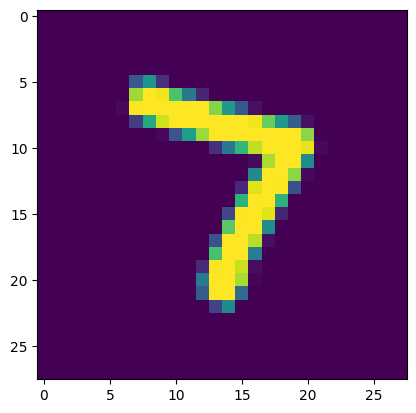

In [3]:
import matplotlib.pyplot as plt


plt.imshow(dataset[0].data['image'][0])

In [4]:
from multivae.models.auto_model import AutoConfig, AutoModel

model = AutoModel.load_from_folder('/home/asenella/dev/multivae_package/reproduce_nexus/seed_1/NEXUS_training_2024-08-30_16-24-40/final_model')

model.eval()

Nexus(
  (decoders): ModuleDict(
    (image): ImageDecoder(
      (upsampler): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Swish()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): Swish()
        (4): Linear(in_features=128, out_features=3136, bias=True)
        (5): Swish()
      )
      (hallucinate): Sequential(
        (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
        (1): Swish()
        (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      )
      (out_process): Sigmoid()
    )
    (audio): SoundDecoder(
      (network): SoundDecoder_network(
        (upsampler): Sequential(
          (0): Linear(in_features=128, out_features=2048, bias=True)
          (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (hallucinate_0): Sequential(
        

In [5]:
from torch.utils.data import DataLoader

mini_batch = next(iter(DataLoader(dataset,batch_size = 2)))

print(mini_batch['labels'])
mini_batch.data['label']

tensor([7, 2])


tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]])

In [8]:
recon = model.predict(mini_batch, cond_mod = ['label'],gen_mod = ['image'],N=10)

In [11]:
recon['image'][0].grad

KeyError: 'image'

In [12]:
for im in recon['image']:
    
    # print(im.detach().numpy().shape)
    # print(im[1])
    plt.figure()
    plt.imshow(im.detach().numpy()[0][0])

(2, 10)
tensor([-2.7271, -2.0744,  7.7970, -1.9102, -2.1702, -2.2642, -1.2243, -3.3890,
        -1.3950, -1.8808], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.6671, -1.8045,  8.0120, -1.9987, -2.2662, -2.3717, -1.2067, -3.4765,
        -1.5523, -2.0179], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.6452, -2.0064,  7.5266, -1.6129, -2.1654, -2.2263, -1.1158, -3.3470,
        -1.3769, -1.8002], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.7080, -2.0023,  7.7889, -1.7112, -2.2457, -2.3192, -1.1789, -3.3876,
        -1.3765, -2.0570], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.5576, -1.9280,  7.1319, -1.0313, -2.1659, -2.3296, -1.1185, -3.3116,
        -1.2511, -1.6897], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.5395, -2.0042,  7.3815, -1.4498, -2.1767, -2.1881, -0.9741, -3.3184,
        -1.4428, -1.7889], grad_fn=<SelectBackward0>)
(2, 10)
tensor([-2.6159, -1.9079,  7.4250, -1.3233, -2.2011, -2.3237, -1.1231, -3.3571,
        -1.3233, -1.8425], grad_fn=<SelectBackward0>)
(2, 10